In [1]:
#import pandas,numpy,matplotlib,seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

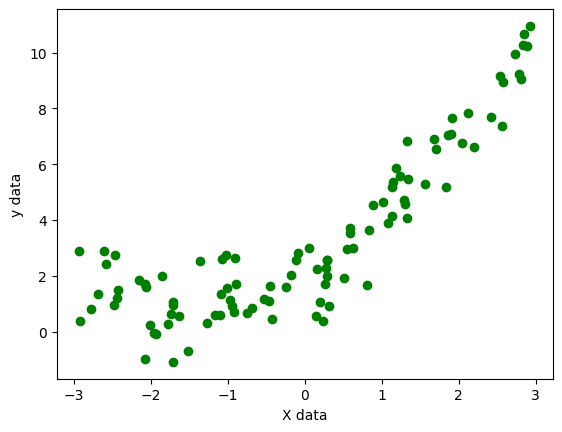

In [2]:
X = 6*np.random.rand(100,1)-3 # 100 random values between -3 and 3, Shape = 100 rows, 1 feature
y = 0.5*X**2 + 1.5*X+2 +np.random.randn(100,1) # y=0.5X^2+1.5X+2 + added random noise (Gaussian noise) to make it realistic
plt.scatter(X,y,color='g')
plt.xlabel('X data')
plt.ylabel('y data')
plt.show()

In [3]:
#train test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
#Linear regression
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train)

LinearRegression()

In [5]:
#prdiction
y_pred = lin_reg.predict(X_test)

In [6]:
#r2 score
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.687670920270102

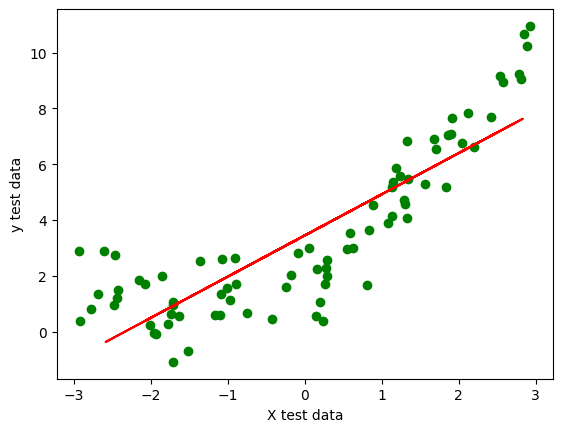

In [7]:
plt.plot(X_test,y_pred,color='r')
plt.scatter(X_train,y_train,color='g')
plt.xlabel('X test data')
plt.ylabel('y test data')
plt.show()

In [8]:
#apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=2,include_bias=True)
# if the degree is 2 if the input is x then it tranform into [1,x,x^2]
# so we get shape as (100,3) becaluse it creates x and x^2 for each features
# so final features bias(1), x, x^2
# include_bias=True, means add 1s so we get [1,x,x2], if False then we get [x,x^2]
X_trainPoly = poly_reg.fit_transform(X_train)
X_testPoly = poly_reg.transform(X_test)


In [9]:
X_trainPoly#it gives the bias  x1 and x1^2

array([[ 1.00000000e+00,  1.57058429e-01,  2.46673502e-02],
       [ 1.00000000e+00, -1.76949228e+00,  3.13110292e+00],
       [ 1.00000000e+00,  1.69981525e+00,  2.88937190e+00],
       [ 1.00000000e+00, -1.35538266e+00,  1.83706216e+00],
       [ 1.00000000e+00,  2.57872362e+00,  6.64981552e+00],
       [ 1.00000000e+00, -2.42491696e+00,  5.88022227e+00],
       [ 1.00000000e+00, -2.46261345e+00,  6.06446498e+00],
       [ 1.00000000e+00,  2.41600286e+00,  5.83706980e+00],
       [ 1.00000000e+00, -1.07888380e+00,  1.16399024e+00],
       [ 1.00000000e+00, -2.14789295e+00,  4.61344411e+00],
       [ 1.00000000e+00,  2.62194567e-01,  6.87459912e-02],
       [ 1.00000000e+00, -1.70985833e+00,  2.92361549e+00],
       [ 1.00000000e+00,  2.85050737e+00,  8.12539225e+00],
       [ 1.00000000e+00,  1.30422786e+00,  1.70101030e+00],
       [ 1.00000000e+00, -8.90228995e-01,  7.92507663e-01],
       [ 1.00000000e+00, -2.92367597e+00,  8.54788116e+00],
       [ 1.00000000e+00, -1.07988553e+00

In [10]:
X_testPoly

array([[ 1.        , -0.11433212,  0.01307183],
       [ 1.        , -1.26768731,  1.60703113],
       [ 1.        , -2.58358269,  6.67489954],
       [ 1.        , -0.45552927,  0.20750692],
       [ 1.        ,  2.56269691,  6.56741543],
       [ 1.        , -0.67805841,  0.45976321],
       [ 1.        ,  2.7303071 ,  7.45457683],
       [ 1.        , -0.53221919,  0.28325727],
       [ 1.        ,  2.83032109,  8.01071748],
       [ 1.        , -0.46694778,  0.21804023],
       [ 1.        , -1.01945471,  1.0392879 ],
       [ 1.        ,  0.50967914,  0.25977282],
       [ 1.        ,  1.01148192,  1.02309568],
       [ 1.        ,  0.58605606,  0.34346171],
       [ 1.        , -0.9180911 ,  0.84289127],
       [ 1.        , -2.07117564,  4.28976855],
       [ 1.        ,  0.29494364,  0.08699175],
       [ 1.        ,  0.31903054,  0.10178049],
       [ 1.        , -2.05670129,  4.23002019],
       [ 1.        , -0.94912128,  0.90083121]])

In [11]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_trainPoly,y_train)
y_pred = lin_reg.predict(X_testPoly)
score=r2_score(y_test,y_pred)
print(score)

0.9029419184663594


In [12]:
print(lin_reg.coef_)

[[0.         1.49681619 0.48222303]]


In [13]:
print(lin_reg.intercept_)

[2.03512204]


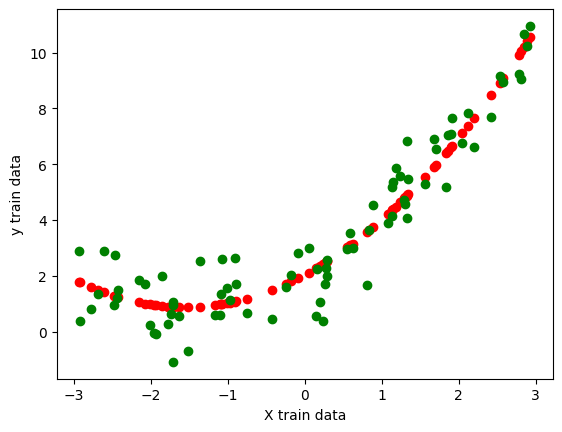

In [14]:
plt.scatter(X_train,lin_reg.predict(X_trainPoly),color='r')
plt.scatter(X_train,y_train,color='g')
plt.xlabel('X train data')
plt.ylabel('y train data')
plt.show()

In [15]:
#Prediction of new dataset
X_new = np.linspace(-3,3,100).reshape(100,1)
X_newPoly = poly_reg.transform(X_new)
y_new = lin_reg.predict(X_newPoly)

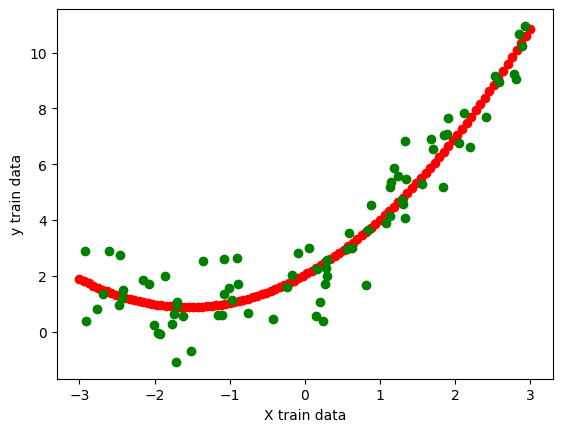

In [16]:
plt.scatter(X_new,y_new,color='r')
plt.scatter(X_train,y_train,color='g')
plt.xlabel('X train data')
plt.ylabel('y train data')
plt.show()

In [17]:
from sklearn.pipeline import Pipeline

In [18]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)

    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()


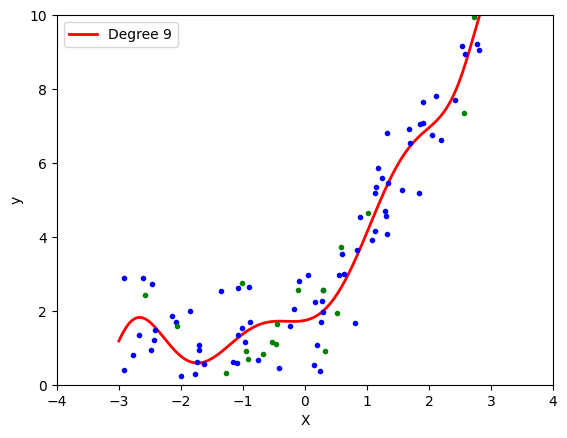

In [23]:
poly_regression(9)